Imports

In [1]:
import notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from platform import python_version
import xgboost as xgb
import graphviz
from datetime import time
from datetime import datetime
from datetime import timedelta, date
import sklearn
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

print(f"python: v {python_version()}")
print(f"Jupyter Notebook: v {notebook.__version__}")
print(f"numpy: v {np.__version__}")
print(f"pandas: v {pd.__version__}")
print(f"seaborn: v {sns.__version__}")
print(f"graphviz: v {graphviz.__version__}")
print(f"matplotlib: v {matplotlib.__version__}")
print(f"sklearn: v {sklearn.__version__}")
print(f"XGBoost: v {xgb.__version__}")

python: v 3.10.12
Jupyter Notebook: v 7.5.5
numpy: v 2.2.6
pandas: v 2.3.3
seaborn: v 0.13.2
graphviz: v 0.21
matplotlib: v 3.10.8
sklearn: v 1.7.2
XGBoost: v 3.2.0


Import Data

In [ ]:
names = ['matthijs', 'manolis', 'robin']
mapping = {
    'matthijs': 2,
    "manolis": 6,
    "robin": 9
}
df_hourlys = []

jet_appliances = ['dishwasher', 'vacuum', 'oven', 'coffee_machine', 'refrigerator', 'washing_machine', 'kettle', 'microwave']

robin_appliances = ['washing_machine', 'toaster', 'kettle', 'TV', 'production']
robin_mapping = {
    'washing_machine': 500,
    'toaster': 1,
    'kettle': 1,
    'TV': 50,
    'production': 500
}

matthijs_appliances = ['TV', 'waterboiler', 'oven', 'washing_machine', 'refrigerator', 'electric_heater', 'dryer']
matthijs_mapping = {
    'TV' : 10,
    'waterboiler' : 100,
    'oven' : 1,
    'washing_machine' : 1,
    'refrigerator' : 5,
    'electric_heater' : 1,
    'dryer' : 10
}

manolis_appliances = ['kettle', 'toaster', 'washer_dryer', 'coffee_machine', 'heatpump', 'TV']
manolis_mapping = {
    'kettle': 1,
    'toaster': 5,
    'washer_dryer': 5,
    'coffee_machine': 1,
    'heatpump': 20,
    'TV': 1
}

thresh = 1
for name in names:
    print(f"Reading data for {name} : ")
    df = pd.read_csv(f"../data/PWC/house_{name}.csv", header=0)
    df.rename(columns={'time': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.tz_localize(None)
    df.rename(columns={'main': 'Volume'}, inplace=True)
    df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
    df = df.set_index('Date')
    hourly = df['Volume'].resample('1h').mean()
    df_hourly = hourly.to_frame(name='Volume').reset_index()
    if name == 'matthijs':
        df_nilm = df[matthijs_appliances].resample('1h').mean().reset_index()
        for device in matthijs_appliances:
            thresh = matthijs_mapping[device]
            df_nilm[device] = pd.to_numeric(df_nilm[device], errors='coerce').fillna(0)
            df_nilm[device] = df_nilm[device].apply(lambda x: 1 if x > thresh else 0)
    elif name == 'robin':
        df_nilm = df[robin_appliances].resample('1h').mean().reset_index()
        for device in robin_appliances:
            thresh = robin_mapping[device]
            df_nilm[device] = pd.to_numeric(df_nilm[device], errors='coerce').fillna(0)
            df_nilm[device] = df_nilm[device].apply(lambda x: 1 if x > thresh else 0)
    elif name == 'manolis':
        df_nilm = df[manolis_appliances].resample('1h').mean().reset_index()
        for device in manolis_appliances:
            thresh = manolis_mapping[device]
            df_nilm[device] = pd.to_numeric(df_nilm[device], errors='coerce').fillna(0)
            df_nilm[device] = df_nilm[device].apply(lambda x: 1 if x > thresh else 0)

    df_hourly = pd.merge(df_hourly, df_nilm, on='Date', how='left')
    df_hourlys.append(df_hourly)


print("CSV read successfully.")


Reading data for manolis : 


Import Temperature Information

In [ ]:

df_temps = pd.read_csv('../data/PWC/hourly_Temp_data.csv')
df_temps.rename(columns={'date': 'Date'}, inplace=True)
df_temps.rename(columns={'temperature_2m': 'Temperature'}, inplace=True)
df_temps['Date'] = pd.to_datetime(df_temps['Date'], errors='coerce').dt.tz_localize(None)
df_temps = df_temps.set_index('Date')
df_temps = df_temps.asfreq("1h")
df_temps = df_temps.dropna(subset=['Temperature'])
df_temps['Temperature'] = pd.to_numeric(df_temps['Temperature'], errors='coerce')
temp_indexs = {}
for i in range(len(df_hourlys)):
    df_hourlys[i] = pd.merge(df_hourlys[i], df_temps, on='Date', how='left')
    temp_indexs[i] = df_hourlys[i].set_index('Date')
    # print last timestamp
    print(f"Last timestamp in df_hourlys[{i}]: {df_hourlys[i]['Date'].max()}")

print("Temperature CSV read successfully.")

Last timestamp in df_hourlys[0]: 2025-01-06 23:00:00
Temperature CSV read successfully.


Feature Engineering

In [ ]:
def add_date_scalar(df):
    df = df.copy()
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['Hour'] = df.Date.dt.hour
    df['Weekday'] = df.Date.dt.weekday  
    return df


def get_type_day(row):
    if row['Weekday'] in (5, 6): 
        return 3
    return 0

def add_type_day(df):
    df = df.copy()
    df['TypeDay'] = df.apply(get_type_day, axis=1)
    return df

# Add lag features while respecting no information after 10:00 AM previous day (offset = 2)
def prepare_data_with_lags(df, lag_start = 1, lag_end = 7, base_offset_days = 2, dropna = True):
    df = df.copy()
    df = add_type_day(df)

    df = df.set_index('Date')

    for k in range(lag_start, lag_end + 1):
        days_back = base_offset_days + (k - 1)
        df[f"lag-{k}"] = df['Volume'].shift(freq=f"{days_back}D")

    if dropna:
        lag_cols = [f"lag-{k}" for k in range(lag_start, lag_end + 1)]
        df = df.dropna(subset=lag_cols)

    df = df.reset_index()
    return df

# Builds a DataFrame with 24 hours
def get_weather_for_day(date_, temp_index, name=None, drop_appliances=None):
    full_range = pd.date_range(date_, periods=25, freq='h')
    df_empty = pd.DataFrame({'Date': full_range})

    if name == 'robin':
        for device in robin_appliances:
            df_empty[device] = 0
    elif name == 'matthijs':
        for device in matthijs_appliances:
            df_empty[device] = 0
    elif name == 'manolis':
        for device in manolis_appliances:
            df_empty[device] = 0

    df_empty['Temperature'] = 0

    if drop_appliances is not None:
        df_empty = df_empty.drop(columns=drop_appliances, errors='ignore')
    
    df = df_empty.tail(25).reset_index(drop=True)
    return df

Replacing NaN values

In [ ]:
group_median = ()
def fill_with_group_median(row):
    if pd.isna(row['Volume']):
        return group_median.loc[(row['Month'], row['Weekday'], row['Hour'])]
    else:
        return row['Volume']
    
df_generals = []
df_analytics = []
for i in range(len(df_hourlys)):
    df_generals.append(add_date_scalar(df_hourlys[i]))
    group_median = (
        df_generals[i]
        .groupby(['Month', 'Weekday', 'Hour'])['Volume']
        .median()
    )
    print(f"For House_{names[i]} :")

    # Data visualization before filling missing values filled with group median

    # plt.figure(figsize=(12, 6))
    # plt.plot(df_generals[i]['Date'], df_generals[i]['Volume'], label='Aggregate Power Consumption')
    # plt.xlabel('Date')
    # plt.ylabel('Power Consumption (W)')
    # plt.title('Aggregate Power Consumption Over Time')
    # plt.legend()
    # plt.show()

    # Number of missing values in Volume before filling with group median
    # missing_count = df_generals[i]['Volume'].isna().sum()
    # print(f"Number of missing values in 'Volume' for House_{names[i]}: {missing_count}, out of {len(df_generals[i])} total entries.")
    # missing_groups = (df_generals[i]['Volume'].isna() != df_generals[i]['Volume'].isna().shift()).cumsum()
    # longest_gap = df_generals[i][df_generals[i]['Volume'].isna()].groupby(missing_groups).size().max()
    # print(f"Longest gap of missing values : {longest_gap} entries, which is {longest_gap / len(df_generals[i]) * 100:.2f}% of total entries.")
    
    df_generals[i]['Volume'] = df_generals[i].apply(fill_with_group_median, axis=1)
    
    # Data visualization after filling missing values filled with group median
    
    # plt.figure(figsize=(12, 6))
    # plt.plot(df_generals[i]['Date'], df_generals[i]['Volume'], label='Aggregate Power Consumption')
    # plt.xlabel('Date')
    # plt.ylabel('Power Consumption (W)')
    # plt.title('Aggregate Power Consumption Over Time')
    # plt.legend()
    # plt.show()
    
    
    df_analytics.append(df_generals[i].copy())
    df_generals[i] = prepare_data_with_lags(df_generals[i])

print("Data preparation completed.")

For House_manolis :
Number of missing values in 'Volume' for House_manolis: 0, out of 672 total entries.
Longest gap of missing values : nan entries, which is nan% of total entries.
Number of missing values in 'Volume' for House_manolis: 0, out of 672 total entries.
Data preparation completed.


Training Function

In [ ]:
def train_xgb_up_to_cutoff(df_general, target_day, max_depth = 6, drop_appliances=None):
    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    df_train = df_general[df_general.Date <= cutoff_dt].copy()

    lag_cols = [c for c in df_train.columns if c.startswith("lag-")]
    df_train = df_train.dropna(subset=lag_cols + ['Volume'])

    X_train = df_train.drop(columns=['Date', 'Volume'])
    if drop_appliances is not None:
        X_train = X_train.drop(columns=drop_appliances, errors='ignore')
    y_train = df_train['Volume']

    model = xgb.XGBRegressor(
        device='cpu',
        n_estimators=200,
        max_depth=max_depth,
        colsample_bytree=0.8,
        learning_rate=0.05,
        subsample=1.0
    )
    model.fit(X_train, y_train)
    return model


Main function to train the model and make predictions

In [ ]:
# Predicts all 24 hours of target_day, using only data up to previous day at 10:00
# This function parameters are:
# - df_general: The general dataframe containing the data.
# - temp_index: The temperature index for the location.
# - target_day: The day for which to make predictions.
# - max_depth: The maximum depth for the model.
# - model: The trained model to use for predictions
# - drop_appliances: List of appliance columns to drop from the features (if any).
# - num: The house number (used to determine which appliances to include in the prediction features).
def predict_day_hourly(df_general, temp_index, target_day, max_depth = 6, model=None, name=None, drop_appliances = None):
    
    if model is None:
        print("Training new model...")
        model = train_xgb_up_to_cutoff(df_general, target_day, max_depth, drop_appliances=drop_appliances)

    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    # Base prediction frame
    df_pred_base = get_weather_for_day(target_day, temp_index, name, drop_appliances=drop_appliances)
    df_pred_base = add_date_scalar(df_pred_base)


    df_hist_for_lags = df_general[df_general.Date <= cutoff_dt].copy()
    df_for_lags = pd.concat([df_hist_for_lags, df_pred_base], ignore_index=True)
    df_for_lags = df_for_lags.sort_values('Date').drop_duplicates(subset=['Date'])
    df_for_lags = prepare_data_with_lags(df_for_lags, lag_start=1, lag_end=7, base_offset_days=2, dropna=False)

    mask_target = df_for_lags['Date'].dt.date == target_day
    df_pred_features = df_for_lags.loc[mask_target].copy()
   
    lag_cols = [c for c in df_pred_features.columns if c.startswith("lag-")]
    df_pred_features = df_pred_features.dropna(subset=lag_cols)

    # Prediction
    X_pred = df_pred_features.drop(columns=['Date', 'Volume'], errors='ignore')
    if drop_appliances is not None:
        X_pred = X_pred.drop(columns=drop_appliances, errors='ignore')
    df_pred_features['Predicted'] = model.predict(X_pred)
    df_result = df_pred_features[['Date', 'Predicted']].sort_values('Date').reset_index(drop=True)
    
    return df_result


Main Functions for Ablation Study

In [ ]:
# This function runs the appliance ablation study by training models with each appliance dropped and evaluating their performance on a daily and hourly basis.
# This function parameters are:
# - df_general: The general dataframe containing the data.
# - temp_index: The temperature index for the location.
# - start_day: The starting day for the evaluation.
# - n_days: The number of days to evaluate.
# - max_depth: The maximum depth for the XGBoost model.
# - appliances: The list of appliance columns to consider for ablation.
def run_appliance_ablation(
    df_general,
    temp_index,
    start_day,
    n_days=7,
    max_depth=6,
    appliances=None
):
    results_day = []
    results_hour = []

    scenarios = [("baseline", None)] + [(f"drop_{a}", [a]) for a in appliances]

    for scenario_name, drop_list in scenarios:
        print(f"\n=== Scenario: {scenario_name} ===")

        model = train_xgb_up_to_cutoff(
            df_general,
            start_day,
            max_depth=max_depth,
            drop_appliances=drop_list
        )
        for d in range(n_days):
            target_day = start_day + timedelta(days=d)

            df_forecast = predict_day_hourly(
                df_general,
                temp_index,
                target_day,
                max_depth=max_depth,
                model=model,
                drop_appliances=drop_list
            )

            df_actual = df_general[
                df_general['Date'].dt.date == target_day
            ][['Date', 'Volume']].reset_index(drop=True)

            df_eval = pd.merge(df_forecast, df_actual, on='Date', how='inner')
            df_eval['Residual'] = df_eval['Volume'] - df_eval['Predicted']

            df_eval = add_date_scalar(df_eval)
            df_eval = add_type_day(df_eval)

            rmse = float(np.sqrt(np.mean(df_eval['Residual'] ** 2)))
            mae = float(np.mean(np.abs(df_eval['Residual'])))

            results_day.append({
                "Scenario": scenario_name,
                "Dropped": None if drop_list is None else drop_list[0],
                "Day": target_day,
                "RMSE": rmse,
                "MAE": mae
            })

            hourly = (
                df_eval
                .groupby(["Hour", "Weekday", "TypeDay"], as_index=False)
                .agg(
                    RMSE=("Residual", lambda x: float(np.sqrt(np.mean(x**2)))),
                    MAE=("Residual", lambda x: float(np.mean(np.abs(x))))
                )
            )
            hourly["Scenario"] = scenario_name
            hourly["Dropped"] = None if drop_list is None else drop_list[0]
            hourly["Day"] = target_day
            results_hour.append(hourly)

    df_day_metrics = pd.DataFrame(results_day)
    df_hour_metrics = pd.concat(results_hour, ignore_index=True)
    return df_day_metrics, df_hour_metrics


# This function runs all combinations of included appliances (from 0 to all) and evaluates their performance on a daily and hourly basis. It allows for limiting the number of scenarios and optionally including the empty set (no appliances).
# This function parameters are:
# - df_general: The general dataframe containing the data.
# - temp_index: The temperature index for the location.
# - start_day: The starting day for the evaluation.
# - n_days: The number of days to evaluate.
# - max_depth: The maximum depth for the XGBoost model.
# - appliances: The list of appliance columns to consider for combinations.
# - include_empty: Whether to include the scenario with no appliances included.
# - limit_scenarios: An optional limit on the number of scenarios to evaluate
def run_all_appliance_combinations(
    df_general,
    temp_index,
    start_day,
    n_days=7,
    max_depth=6,
    appliances=None,
    include_empty=False,
    limit_scenarios=None,
    name=None
):

    results_day = []
    results_hour = []

    subset_sizes = range(0 if include_empty else 1, len(appliances) + 1)
    all_subsets = []
    for r in subset_sizes:
        all_subsets.extend(itertools.combinations(appliances, r))

    if limit_scenarios is not None:
        all_subsets = all_subsets[:limit_scenarios]

    for included in all_subsets:
        included = list(included)
        dropped = [a for a in appliances if a not in included]

        scenario_name = "incl_" + ("none" if len(included) == 0 else "_".join([a.replace("Appliance", "A") for a in included]))
        print(f"\n=== Scenario: {scenario_name} (included={len(included)}, dropped={len(dropped)}) ===")

        model = train_xgb_up_to_cutoff(
            df_general,
            start_day,
            max_depth=max_depth,
            drop_appliances=dropped if len(dropped) > 0 else None
        )

        for d in range(n_days):
            target_day = start_day + timedelta(days=d)

            df_forecast = predict_day_hourly(
                df_general,
                temp_index,
                target_day,
                max_depth=max_depth,
                model=model,
                drop_appliances=dropped if len(dropped) > 0 else None,
                name=name
            )

            df_actual = df_general[
                df_general['Date'].dt.date == target_day
            ][['Date', 'Volume']].reset_index(drop=True)

            df_eval = pd.merge(df_forecast, df_actual, on='Date', how='inner')
            df_eval['Residual'] = df_eval['Volume'] - df_eval['Predicted']

            df_eval = add_date_scalar(df_eval)
            df_eval = add_type_day(df_eval)

            rmse = float(np.sqrt(np.mean(df_eval['Residual'] ** 2)))
            mae = float(np.mean(np.abs(df_eval['Residual'])))

            results_day.append({
                "Scenario": scenario_name,
                "Included": ",".join(included) if len(included) else "",
                "Dropped": ",".join(dropped) if len(dropped) else "",
                "n_included": len(included),
                "Day": target_day,
                "RMSE": rmse,
                "MAE": mae
            })

            hourly = (
                df_eval
                .groupby(["Hour", "Weekday", "TypeDay"], as_index=False)
                .agg(
                    RMSE=("Residual", lambda x: float(np.sqrt(np.mean(x**2)))),
                    MAE=("Residual", lambda x: float(np.mean(np.abs(x))))
                )
            )
            hourly["Scenario"] = scenario_name
            hourly["Included"] = ",".join(included) if len(included) else ""
            hourly["Dropped"] = ",".join(dropped) if len(dropped) else ""
            hourly["n_included"] = len(included)
            hourly["Day"] = target_day
            results_hour.append(hourly)

    df_day_metrics = pd.DataFrame(results_day)
    df_hour_metrics = pd.concat(results_hour, ignore_index=True)
    return df_day_metrics, df_hour_metrics

# This function calculates the marginal contribution of each appliance to the performance metric (e.g., MAE) along with the standard deviation of that contribution across different subsets of included appliances.
# This function parameters are:
# - df_day_metrics: The DataFrame containing the daily performance metrics for each scenario.
# - appliances: The list of appliance columns to consider for calculating marginal contributions.
# - metric: The performance metric to use for calculating marginal contributions (default is "MAE").
def marginal_contribution_with_std(df_day_metrics, appliances=None, metric="MAE"):
    df = df_day_metrics.copy()
    df["IncludedSet"] = df["Included"].fillna("").apply(lambda s: frozenset([x for x in s.split(",") if x]))
    perf = df.groupby("IncludedSet")[metric].mean().to_dict()

    rows = []
    for a in appliances:
        deltas = [perf[S | {a}] - perf[S] for S in perf if (a not in S and (S | {a}) in perf)]
        rows.append({
            "Appliance": a,
            "marginal_mean": float(np.mean(deltas)) if deltas else np.nan,
            "marginal_std": float(np.std(deltas, ddof=1)) if len(deltas) > 1 else np.nan,
            "n": int(len(deltas))
        })
    return pd.DataFrame(rows).sort_values("marginal_mean")


Main Loop for Ablation Study


Predictions for house_manolis:

Results for house_manolis : 

=== Scenario: incl_none (included=0, dropped=6) ===



=== Scenario: incl_kettle (included=1, dropped=5) ===

=== Scenario: incl_toaster (included=1, dropped=5) ===

=== Scenario: incl_washer_dryer (included=1, dropped=5) ===

=== Scenario: incl_coffee_machine (included=1, dropped=5) ===

=== Scenario: incl_heatpump (included=1, dropped=5) ===

=== Scenario: incl_TV (included=1, dropped=5) ===

=== Scenario: incl_kettle_toaster (included=2, dropped=4) ===

=== Scenario: incl_kettle_washer_dryer (included=2, dropped=4) ===

=== Scenario: incl_kettle_coffee_machine (included=2, dropped=4) ===

=== Scenario: incl_kettle_heatpump (included=2, dropped=4) ===

=== Scenario: incl_kettle_TV (included=2, dropped=4) ===

=== Scenario: incl_toaster_washer_dryer (included=2, dropped=4) ===

=== Scenario: incl_toaster_coffee_machine (included=2, dropped=4) ===

=== Scenario: incl_toaster_heatpump (included=2, dropped=4) ===

=== Scenario: incl_toaster_TV (included=2, dropped=4) ===

=== Scenario: incl_washer_dryer_coffee_machine (included=2, dropped=4

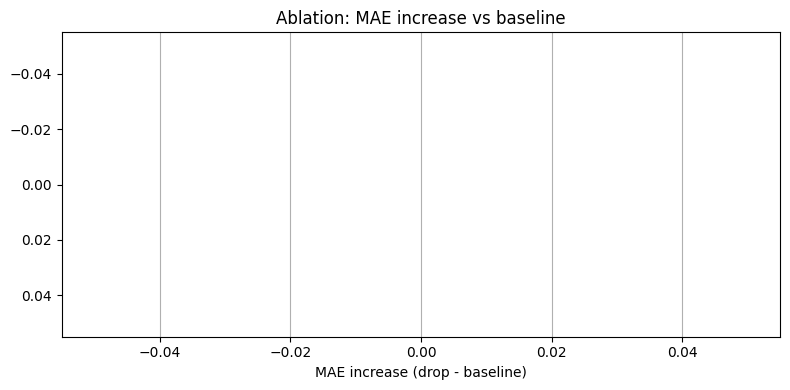

In [ ]:
metrics_summary = []
best_models = []

for i in range(len(names)):
    print(f"\nPredictions for house_{names[i]}:\n")
    tdays = 8
    if names[i]  == 'matthijs':
        target_date = date(2024, 12, 25)
        appliances = matthijs_appliances
    elif names[i] == 'robin':
        target_date = date(2025, 4, 12)
        appliances = robin_appliances
    elif names[i] == 'manolis':
        target_date = date(2024, 12, 30)
        appliances = manolis_appliances
        
    df_general = df_generals[i]
    temp_index = temp_indexs[i]
    print(f"Results for house_{names[i]} : ")
    df_day_metrics_all, df_hour_metrics_all = run_all_appliance_combinations(
        df_general=df_general,
        temp_index=temp_index,
        start_day=target_date,
        n_days=7,
        max_depth=6,
        include_empty=True,
        limit_scenarios=None,
        appliances=appliances,
        name=names[i]
    )
    
    best = (
        df_day_metrics_all
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )

    print(best.head(20))
    marginal_importance = marginal_contribution_with_std(df_day_metrics_all, appliances=appliances, metric="MAE")
    print("\nMarginal contribution of each appliance (from combos):")
    print(marginal_importance)



Save to File

In [ ]:
df_day_metrics_all.to_csv(f"Predictions/ablation_results_pwc_house_{names[i]}.csv", index=False) 
df_hour_metrics_all.to_csv(f"Predictions/ablation_results_pwc_hourly_house_{names[i]}.csv", index=False)